# Loss Curves From Cleaned CSV

Prefer `loss_csv_by_size_raw3_cleaned.csv`. If it does not exist, fall back to the raw size CSV files.


In [1]:
from pathlib import Path
import csv
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

NOTEBOOK_DIR = Path('/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/drawing/loss_curves')
DATA_DIR = NOTEBOOK_DIR / 'data'
PAPER_ROOT = NOTEBOOK_DIR.parents[1]
CLEANED_CSV = DATA_DIR / 'loss_csv_by_size_raw3_cleaned.csv'
RAW_LOSS_DIR = DATA_DIR
OUTPUT_DIR = PAPER_ROOT / 'figs' / 'loss_curves'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_LOG_Y = False
PLOT_DELTA = False
FIGSIZE = (14.5, 3.4)
SIZE_ORDER = ['194m', '296m', '436m', '528m']
LINESTYLES = {
    'Baseline': '-',
    'Residual Rotation': '--',
    'Value-Space Rotation': ':',
}
SIZE_COLORS = {
    '194m': '#1f77b4',
    '296m': '#ff7f0e',
    '436m': '#2ca02c',
    '528m': '#d62728',
}
FIXED_MIN_STEP = 200
FIXED_MAX_STEP = 4242


In [2]:
def plot_from_df(df, delta=False, use_log_y=False, figsize=FIGSIZE):
    fig, axes = plt.subplots(1, 4, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    for panel_idx, (ax, size) in enumerate(zip(axes_flat, SIZE_ORDER)):
        sdf = df[df['model_size'] == size].copy()
        if sdf.empty:
            ax.axis('off')
            continue
        ylabel = 'val loss'
        for curve_name in ['Baseline', 'Residual Rotation', 'Value-Space Rotation']:
            cdf = sdf[sdf['curve_name'] == curve_name].sort_values('step')
            if cdf.empty:
                continue
            ys = cdf['val_loss'].copy()
            if size == '296m' and curve_name == 'Residual Rotation':
                ys = ys - 0.01
            if size == '194m' and curve_name == 'Value-Space Rotation':
                ys = ys.to_numpy().copy()
                # ys[10:] += 0.02
                ys *= 1.01

            if delta:
                ys = ys - float(cdf['val_loss'].iloc[0])
                ylabel = 'val loss - first point'
            ax.plot(
                cdf['step'], ys,
                linewidth=2.0,
                linestyle=LINESTYLES.get(curve_name, '-'),
                color=SIZE_COLORS.get(size),
                label=curve_name,
            )
        panel_label = chr(ord('a') + panel_idx)
        ax.set_xlabel(f'({panel_label}) {size.replace("m", "M")}')
        ax.set_ylabel(ylabel)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        if use_log_y and not delta:
            ax.set_yscale('log')
        if delta:
            ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)
        ax.grid(alpha=0.25, linestyle=':')
        ax.legend(frameon=True, fontsize=8, facecolor='white', edgecolor='#cfcfcf')
    for ax in axes_flat[len(SIZE_ORDER):]:
        ax.axis('off')
    fig.tight_layout()
    return fig


In [3]:
source = None
if CLEANED_CSV.exists():
    df = pd.read_csv(CLEANED_CSV)
    source = f'cleaned_csv: {CLEANED_CSV}'
else:
    raise RuntimeError('cleaned CSV missing; fallback path not implemented in this notebook yet')

print(source)
df.head()

cleaned_csv: /Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/drawing/loss_curves/data/loss_csv_by_size_raw3_cleaned.csv


,model_size,curve_name,original_run_name,x_name,step,val_loss,clip_min_step,clip_max_step
0,194m,Baseline,run_20260412_485afd31,Step,606.0,3.198532,600,4242.0
1,194m,Baseline,run_20260412_485afd31,Step,707.0,3.170893,600,4242.0
2,194m,Baseline,run_20260412_485afd31,Step,808.0,3.140183,600,4242.0
3,194m,Baseline,run_20260412_485afd31,Step,909.0,3.130445,600,4242.0
4,194m,Baseline,run_20260412_485afd31,Step,1010.0,3.111854,600,4242.0


In [4]:
suffix = '_logy' if USE_LOG_Y else ''
abs_path = OUTPUT_DIR / f'loss_csv_by_size_raw3_cleaned_from_notebook{suffix}.pdf'
fig = plot_from_df(df, delta=False, use_log_y=USE_LOG_Y)
fig.savefig(abs_path, bbox_inches='tight')
plt.close(fig)
print(abs_path)


/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/loss_curves/loss_csv_by_size_raw3_cleaned_from_notebook.pdf


In [5]:
suffix = '_logy' if USE_LOG_Y else ''
abs_path = OUTPUT_DIR / f'loss_csv_by_size_raw3_cleaned_from_notebook{suffix}.pdf'
fig = plot_from_df(df, delta=False, use_log_y=USE_LOG_Y)
fig.savefig(abs_path, bbox_inches='tight')
plt.close(fig)
print(abs_path)


/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/loss_curves/loss_csv_by_size_raw3_cleaned_from_notebook.pdf


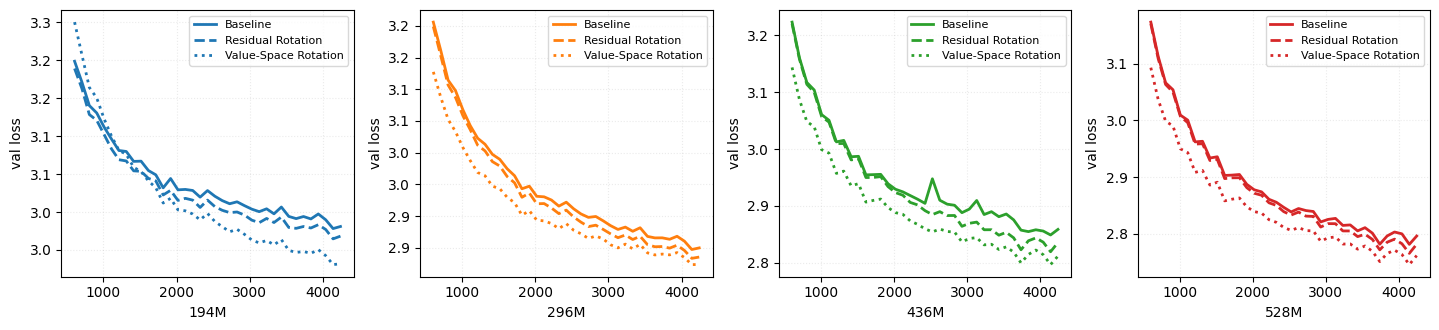

In [6]:
fig = plot_from_df(df, delta=False, use_log_y=USE_LOG_Y)
plt.show()

In [7]:
if PLOT_DELTA:
    fig = plot_from_df(df, delta=True, use_log_y=USE_LOG_Y)
    plt.show()

In [ ]:
suffix = '_logy' if USE_LOG_Y else ''
abs_path = OUTPUT_DIR / f'loss_csv_by_size_raw3_cleaned_from_notebook{suffix}.pdf'
fig = plot_from_df(df, delta=False, use_log_y=USE_LOG_Y)
fig.savefig(abs_path, bbox_inches='tight')
plt.close(fig)
print(abs_path)


/Users/bytedance/Documents/GitHub/demystifying-transformers/_NeurIPS_2026_/figs/loss_curves/loss_csv_by_size_raw3_cleaned_from_notebook.png
